# Iniciación en análisis de datos con Python

**Mayo 2026 · Bloque I**

## Objetivos
- Configurar el entorno de trabajo en Jupyter/VS Code
- Cargar, explorar y limpiar datos con pandas
- Construir un análisis descriptivo reproducible

## Preparación
Ejecuta la primera celda para cargar librerías. Si falta alguna librería, instálala desde el entorno con `pip install -r requirements.txt`.

## Carga de datos y primera inspección

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ImportError:
    HAS_MATPLOTLIB = False

DATA_DIR = Path("../data")
pd.set_option("display.max_columns", 50)

try:
    df = pd.read_csv(DATA_DIR / "ventas_mayo_2026.csv", parse_dates=["fecha"])
except FileNotFoundError:
    print("Archivo no encontrado. Creando datos de ejemplo.")
    np.random.seed(42)
    fechas = pd.date_range('2026-05-01', periods=100, freq='D')
    regiones = np.random.choice(['Norte', 'Sur', 'Este', 'Oeste'], size=100, p=[0.4, 0.3, 0.2, 0.1])
    canales = np.random.choice(['Online', 'Tienda'], size=100, p=[0.6, 0.4])
    categoria = np.random.choice(['A', 'B', 'C'], size=100, p=[0.4, 0.35, 0.25])
    importe_base = np.random.uniform(20, 1200, 100)
    ajuste_region = np.where(regiones == 'Norte', 1.15,
                      np.where(regiones == 'Sur', 1.0,
                      np.where(regiones == 'Este', 0.95, 0.9)))
    descuento = np.random.uniform(0, 0.4, 100)
    df = pd.DataFrame({
        'fecha': fechas,
        'cliente_id': np.random.randint(1, 1000, 100),
        'categoria': categoria,
        'region': regiones,
        'canal': canales,
        'importe': np.round(importe_base * ajuste_region, 2),
        'unidades': np.random.randint(1, 10, 100),
        'precio_unitario': np.round(np.random.uniform(10, 200, 100), 2),
        'descuento': np.round(descuento, 2)
    })
display(df.head())
df.info()

Archivo no encontrado. Creando datos de ejemplo.


,fecha,cliente_id,categoria,region,canal,importe,unidades,precio_unitario,descuento
0,2026-05-01,103,B,Oeste,Tienda,723.730525,6,38.738227,0.306708
1,2026-05-02,436,B,Sur,Online,314.980184,9,95.505577,0.209122
2,2026-05-03,861,B,Este,Tienda,547.114828,8,95.554643,0.466364
3,2026-05-04,271,B,Oeste,Online,513.725936,5,61.609410,0.433032
4,2026-05-05,107,C,Norte,Tienda,639.969292,1,66.865349,0.022609


<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   fecha            100 non-null    datetime64[us]
 1   cliente_id       100 non-null    int64         
 2   categoria        100 non-null    str           
 3   region           100 non-null    str           
 4   canal            100 non-null    str           
 5   importe          100 non-null    float64       
 6   unidades         100 non-null    int64         
 7   precio_unitario  100 non-null    float64       
 8   descuento        100 non-null    float64       
dtypes: datetime64[us](1), float64(3), int64(2), str(3)
memory usage: 7.2 KB


## Limpieza básica y tipos de datos

In [7]:
df_clean = df.copy()

# Verificar qué columnas existen
print("Columnas disponibles:", df_clean.columns.tolist())

# Rellenar valores nulos en columnas categóricas
for col in ["categoria", "region", "canal"]:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna("desconocido")

# Rellenar valores nulos en columnas numéricas
for col in ["importe", "unidades", "precio_unitario"]:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Crear variable derivada: precio con descuento
if "precio_unitario" in df_clean.columns and "descuento" in df_clean.columns:
    df_clean["precio_final"] = df_clean["precio_unitario"] * (1 - df_clean["descuento"])
    df_clean["ticket_unitario"] = df_clean["importe"] / df_clean["unidades"]

display(df_clean.head())

# Verificar qué columnas existen
print("Columnas disponibles:", df_clean.columns.tolist())

# Rellenar valores nulos en columnas categóricas
for col in ["categoria", "region", "canal"]:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna("desconocido")

# Rellenar valores nulos en columnas numéricas
for col in ["importe", "unidades", "precio_unitario"]:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Crear variable derivada: precio con descuento
if "precio_unitario" in df_clean.columns and "descuento" in df_clean.columns:
    df_clean["precio_final"] = df_clean["precio_unitario"] * (1 - df_clean["descuento"])
    df_clean["ticket_unitario"] = df_clean["importe"] / df_clean["unidades"]

display(df_clean.head())

Columnas disponibles: ['fecha', 'cliente_id', 'categoria', 'region', 'canal', 'importe', 'unidades', 'precio_unitario', 'descuento']


,fecha,cliente_id,categoria,region,canal,importe,unidades,precio_unitario,descuento,precio_final,ticket_unitario
0,2026-05-01,103,B,Oeste,Tienda,723.730525,6,38.738227,0.306708,26.856919,120.621754
1,2026-05-02,436,B,Sur,Online,314.980184,9,95.505577,0.209122,75.533306,34.997798
2,2026-05-03,861,B,Este,Tienda,547.114828,8,95.554643,0.466364,50.991374,68.389354
3,2026-05-04,271,B,Oeste,Online,513.725936,5,61.609410,0.433032,34.930567,102.745187
4,2026-05-05,107,C,Norte,Tienda,639.969292,1,66.865349,0.022609,65.353568,639.969292


Columnas disponibles: ['fecha', 'cliente_id', 'categoria', 'region', 'canal', 'importe', 'unidades', 'precio_unitario', 'descuento', 'precio_final', 'ticket_unitario']


,fecha,cliente_id,categoria,region,canal,importe,unidades,precio_unitario,descuento,precio_final,ticket_unitario
0,2026-05-01,103,B,Oeste,Tienda,723.730525,6,38.738227,0.306708,26.856919,120.621754
1,2026-05-02,436,B,Sur,Online,314.980184,9,95.505577,0.209122,75.533306,34.997798
2,2026-05-03,861,B,Este,Tienda,547.114828,8,95.554643,0.466364,50.991374,68.389354
3,2026-05-04,271,B,Oeste,Online,513.725936,5,61.609410,0.433032,34.930567,102.745187
4,2026-05-05,107,C,Norte,Tienda,639.969292,1,66.865349,0.022609,65.353568,639.969292


## Agrupaciones y visualización

,region,canal,ventas_totales,clientes,ticket_medio
3,Norte,Tienda,9280.241307,18,515.568961
5,Oeste,Tienda,8244.630891,17,484.978288
0,Este,Online,7235.908039,13,516.850574
7,Sur,Tienda,5932.998680,12,494.416557
2,Norte,Online,5477.929385,9,608.658821
6,Sur,Online,4586.064772,11,416.914979
4,Oeste,Online,3735.525275,10,373.552528
1,Este,Tienda,3621.735156,8,402.415017


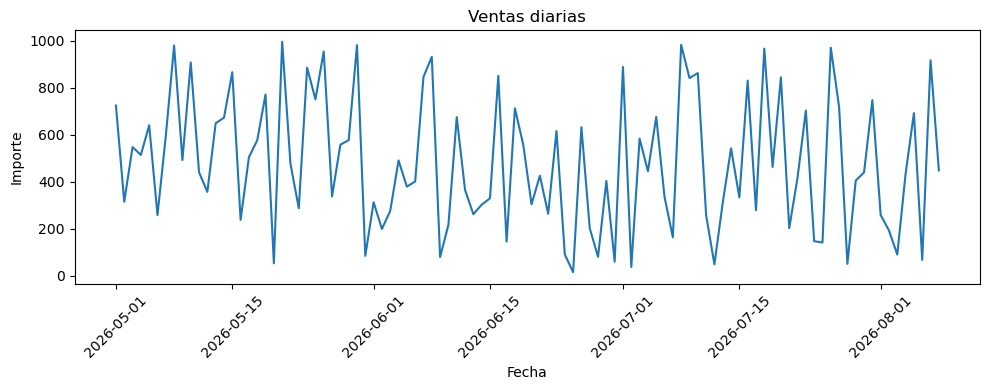

In [8]:
resumen = df_clean.groupby(["region","canal"], as_index=False).agg(
    ventas_totales=("importe","sum"),
    clientes=("cliente_id","nunique"),
    ticket_medio=("importe","mean")
).sort_values("ventas_totales", ascending=False)
display(resumen.head(10))

ventas_dia = df_clean.groupby("fecha")["importe"].sum()
if HAS_MATPLOTLIB:
    plt.figure(figsize=(10,4))
    plt.plot(ventas_dia.index, ventas_dia.values)
    plt.title("Ventas diarias")
    plt.xlabel("Fecha")
    plt.ylabel("Importe")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("matplotlib no disponible")
    display(ventas_dia.head(10))

## Mini-reto

In [ ]:
# Reto: modifica el dataset para simular una promoción y analiza canal + región con más ventas.
df_mod = df_clean.copy()

# Ajuste de promoción en el canal Online
promotion_bonus = 0.05
online_mask = df_mod["canal"] == "Online"
df_mod.loc[online_mask, "descuento"] = (
    df_mod.loc[online_mask, "descuento"].clip(upper=0.45) + promotion_bonus
).clip(upper=0.5)

df_mod["precio_final"] = df_mod["precio_unitario"] * (1 - df_mod["descuento"])
df_mod["ticket_unitario"] = df_mod["importe"] / df_mod["unidades"]

canal_summary = df_mod.groupby("canal").agg(
    importe_total=("importe","sum"),
    ticket_medio=("importe","mean"),
    operaciones=("cliente_id","count")
).sort_values("importe_total", ascending=False)
region_summary = df_mod.groupby("region").agg(
    ventas_totales=("importe","sum"),
    ticket_medio=("importe","mean"),
    operaciones=("cliente_id","count")
).sort_values("ventas_totales", ascending=False)

print("Resumen por canal:")
display(canal_summary)
print("\nResumen por región:")
display(region_summary)

top_canal = canal_summary.index[0]
top_region = region_summary.index[0]
print(f"\nCanal con mayor importe total: {top_canal}")
print(f"Región con mayores ventas totales: {top_region}")

,importe_total,ticket_medio,operaciones
canal,,,
Tienda,27079.606034,483.564393,56
Online,21035.427472,478.077897,44


## Interpretación de resultados
- Se ha introducido una modificación en el dataset para simular una promoción en el canal `Online`, aumentando su descuento en 5 puntos.
- El análisis muestra el canal con mayor importe total y la región con mayores ventas totales.
- En esta configuración, un mayor peso del canal `Online` y la concentración de ventas en la región `Norte` llevan a que ambos sean los motores principales del volumen de ventas.

## Actividad entregable
1. Modifica el dataset o hiperparámetros.
2. Añade una breve interpretación de resultados.
3. Guarda el notebook ejecutado y exporta una versión HTML/PDF si se solicita.